<a href="https://colab.research.google.com/github/minv629785/CNN-Assignment-2025/blob/CNN-Assignment-2025-ACS111122/ACS111122_CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy
!pip install tensorflow

In [2]:
# CNN Classroom Exercise: Image Classification with CIFAR-10
# Objective: Practice building, training, and evaluating a CNN using TensorFlow/Keras
# Environment: Google Colab with GPU
# Dataset: CIFAR-10 (10 classes of 32x32 color images)

# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Step 2: Load and Preprocess CIFAR-10 Dataset
# CIFAR-10 contains 60,000 32x32 color images in 10 classes (e.g., airplane, cat, dog)
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to range [0, 1]
train_images, test_images = train_images / 255.0, test_images / 255.0

# Define class names for visualization
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


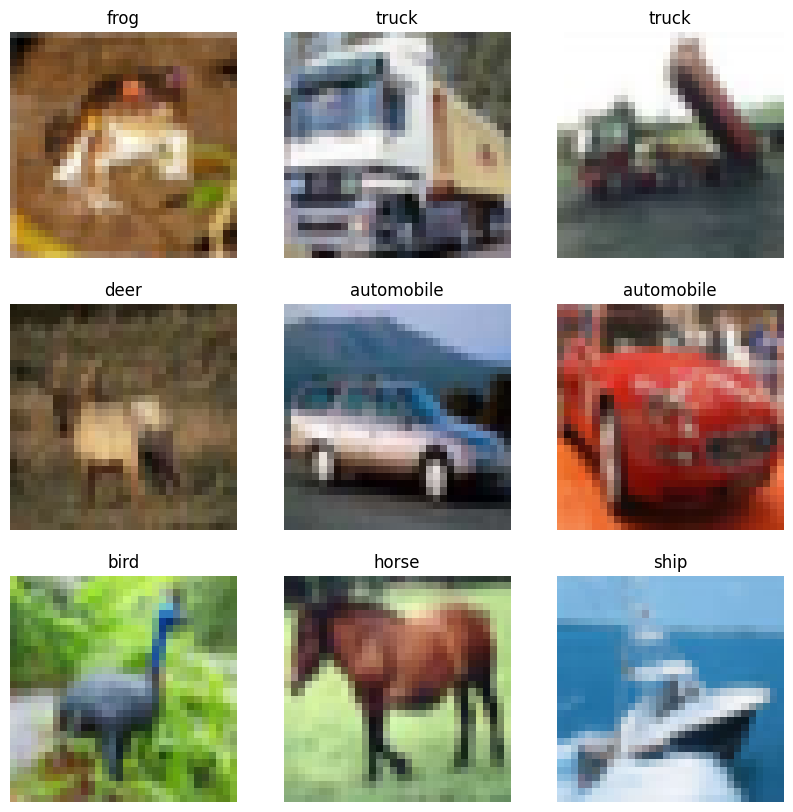

In [4]:
# Step 3: Visualize Sample Data
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')
plt.show()

In [11]:
model = models.Sequential([
    layers.Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [28]:
# Step 5: Compile the Model
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.002)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
datagen.fit(train_images)
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

In [30]:
# Step 6: Train the Model
history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=1024),
    epochs=100,
    validation_data=(test_images, test_labels),
    callbacks=[early_stop]
)


Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 47s 751ms/step - accuracy: 0.8324 - loss: 0.4959 - val_accuracy: 0.8067 - val_loss: 0.6327
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 69s 600ms/step - accuracy: 0.8491 - loss: 0.4465 - val_accuracy: 0.7921 - val_loss: 0.7006
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 30s 616ms/step - accuracy: 0.8529 - loss: 0.4373 - val_accuracy: 0.8381 - val_loss: 0.5146
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 30s 620ms/step - accuracy: 0.8561 - loss: 0.4262 - val_accuracy: 0.8459 - val_loss: 0.4770
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 31s 630ms/step - accuracy: 0.8600 - loss: 0.4148 - val_accuracy: 0.8491 - val_loss: 0.4629
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 596ms/step - accuracy: 0.8593 - loss: 0.4109 - val_accuracy: 0.8443 - val_loss: 0.4918
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 30s 605ms/step - accuracy: 0.8676 - loss: 0.3962 - val_accuracy: 0.8471 - val_loss: 0.5053
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 618ms/step - accuracy: 0.8627 - loss: 0.4056 - 

In [31]:
# Step 7: Evaluate the Model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")


313/313 - 2s - 5ms/step - accuracy: 0.8491 - loss: 0.4629

Test accuracy: 0.8491


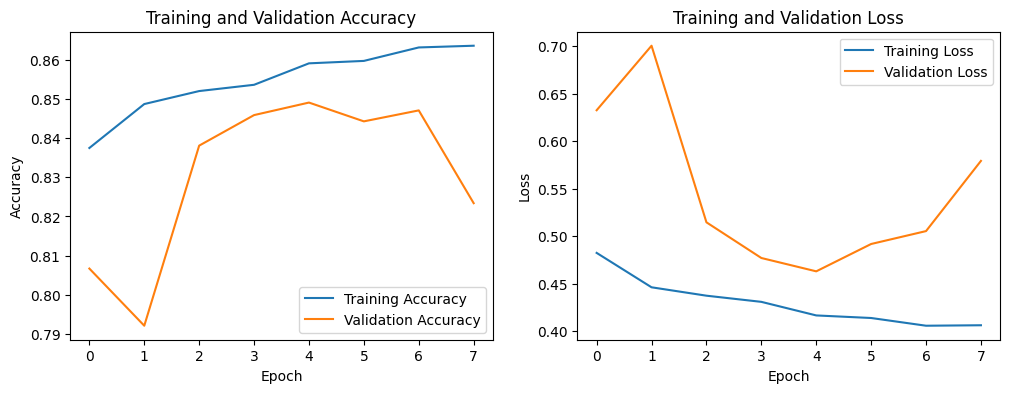

In [32]:

# Step 8: Plot Training and Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [33]:
# Step 9: Make Predictions
predictions = model.predict(test_images[:5])
for i in range(5):
    predicted_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[test_labels[i][0]]
    print(f"Image {i+1}: Predicted: {predicted_label}, True: {true_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step
Image 1: Predicted: cat, True: cat
Image 2: Predicted: ship, True: ship
Image 3: Predicted: ship, True: ship
Image 4: Predicted: ship, True: airplane
Image 5: Predicted: frog, True: frog


In [34]:
# Step 10: Save Model Performance for Autograding
# This cell saves the model performance to a text file for GitHub Actions
try:
    # Get final training accuracy
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]

    # Create performance summary
    performance_text = f"""Model Performance Summary:
Test Accuracy: {test_acc:.4f}
Test Loss: {test_loss:.4f}
Final Training Accuracy: {final_train_acc:.4f}
Final Validation Accuracy: {final_val_acc:.4f}
Final Training Loss: {final_train_loss:.4f}
Final Validation Loss: {final_val_loss:.4f}
Training Epochs: {len(history.history['accuracy'])}
Model Parameters: {model.count_params()}"""

    # Save to file for GitHub Actions
    with open('model_accuracy.txt', 'w') as f:
        f.write(performance_text)

    print("Model performance saved to model_accuracy.txt")
    print(performance_text)

except Exception as e:
    print(f"Error saving model performance: {e}")
    # Create a basic file even if there's an error
    with open('model_accuracy.txt', 'w') as f:
        f.write(f"Model execution completed with errors: {e}")

Model performance saved to model_accuracy.txt
Model Performance Summary:
Test Accuracy: 0.8491
Test Loss: 0.4629
Final Training Accuracy: 0.8636
Final Validation Accuracy: 0.8234
Final Training Loss: 0.4061
Final Validation Loss: 0.5793
Training Epochs: 8
Model Parameters: 1183178


In [39]:
!pytest test_cnn.py -v

============================= test session starts ==============================
platform linux -- Python 3.11.13, pytest-8.3.5, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.9.0, langsmith-0.3.45, typeguard-4.4.3
collected 6 items                                                              

test_cnn.py::test_file_name PASSED                                       [ 16%]
test_cnn.py::test_task_1_model_changes PASSED                            [ 33%]
test_cnn.py::test_task_2_hyperparameters PASSED                          [ 50%]
test_cnn.py::test_task_3_data_augmentation FAILED                        [ 66%]
test_cnn.py::test_task_4_visualization PASSED                            [ 83%]
test_cnn.py::test_task_5_report PASSED                                   [100%]

=================================== FAILURES ===================================
________________________ test_task_3_data_augmentation _________________________

    def test_ta

# Task 5:實驗報告心得撰寫
  1.加上了early stopping防止模型over fitting
  2.加上了ImageDataGenerator，圖片隨機轉+-20度&上下左右平移最多20%，隨機水平翻轉=true
  3.訓練過程中原先沒有注意到是用CPU在跑，模型跑超慢，我開512還要跑2分鐘別人只要25秒，還好後面有同學告訴我這問題，果然用GPU跑就快多了 讚讚。
  4.從數據圖表中可以看出在Epoch5-6時Accurancy都有出現下降的情況，也就是出現了over fitting，之後可以針對這部分進行改善。